# **04장. 로지스틱 회귀 모델**


[실습 04-01]

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 41.5 MB/s eta 0:00:00


[실습 04-02]

In [ ]:
dat={
'나이': [25, 33, 55],
'스마트폰': ['체리', '망고', '키위']}
df=pd.DataFrame(dat)
df

,나이,스마트폰
0,25,체리
1,33,망고
2,55,키위


[실습 04-03]

In [ ]:
y_oh=pd.get_dummies(df["스마트폰"]).astype(int)  # 0/1
#y_oh=pd.get_dummies(df["스마트폰"])             # True/False
print("원핫 인코딩 결과")
print(y_oh)

원핫 인코딩 결과
   망고  체리  키위
0   0   1   0
1   1   0   0
2   0   0   1


[실습 04-04]

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_idx= le.fit_transform(df['스마트폰'])
print("라벨 인코딩 결과")
print(y_idx)

라벨 인코딩 결과
[1 0 2]


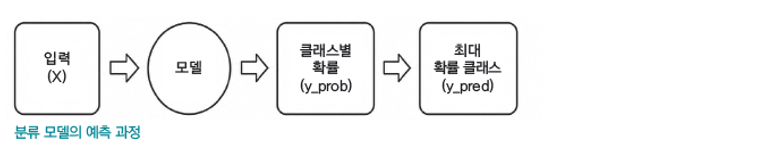



---
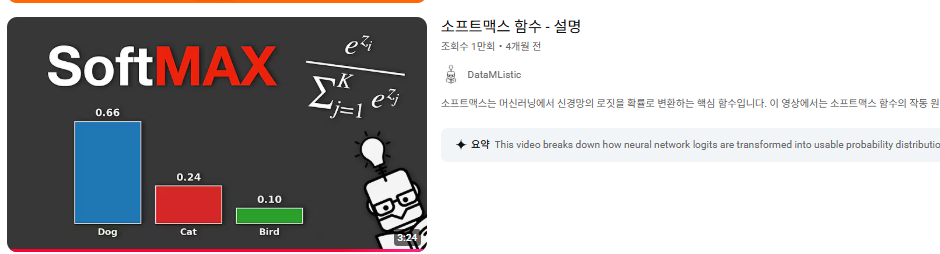


https://www.youtube.com/watch?v=oJU6-qW6xZU

이 동영상은 클래스별 점수를 확률로 변환하는 소프트맥스 함수를 쉽게 설명하고 있습니다.

또한 **Temperature**를 사용해서 소프트맥스 확률을 변형하는 방법도 설명하고 있는데, 이것은 13장에서 사용됩니다.


---



[실습 04-05]

In [ ]:
# 입력 변수 지정
X=1

# 클래스별 파라미터 지정
w = np.random.uniform(-1, 1, 3)
b = np.random.uniform(-1, 1, 3)
print("w=", w)
print("b=", w)

# 점수 계산(선형 변환)
z0=w[0]*X+b[0]
z1=w[1]*X+b[1]
z2=w[2]*X+b[2]

# 확률 변환(소프트맥스 함수)
p0=np.exp(z0)/(np.exp(z0)+np.exp(z1)+np.exp(z2))
p1=np.exp(z1)/(np.exp(z0)+np.exp(z1)+np.exp(z2))
p2=np.exp(z2)/(np.exp(z0)+np.exp(z1)+np.exp(z2))

# 확률 출력
pd.DataFrame([p0, p1, p2], columns=["클래스별 확률"])

w= [ 0.06530186  0.6185342  -0.17713991]
b= [ 0.06530186  0.6185342  -0.17713991]


,클래스별 확률
0,0.284252
1,0.569912
2,0.145837


[실습 04-06]

In [ ]:
df=pd.read_csv("브랜드선택.csv", encoding='cp949')
df

,표본_id,나이,소득,스마트폰
0,1,30,380,망고
1,2,33,290,키위
2,3,63,950,체리
3,4,24,420,망고
4,5,22,370,체리
...,...,...,...,...
195,196,43,480,키위
196,197,22,280,망고
197,198,50,730,체리
198,199,35,460,키위


[실습 04-07]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   표본_id   200 non-null    int64 
 1   나이      200 non-null    int64 
 2   소득      200 non-null    int64 
 3   스마트폰    200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


[실습 04-08]

In [ ]:
df["스마트폰"].value_counts()

,count
스마트폰,
망고,97
키위,65
체리,38


<Axes: xlabel='스마트폰'>

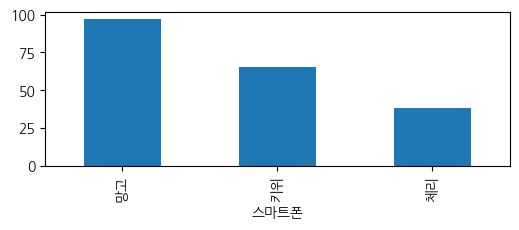

In [ ]:
plt.figure(figsize=(6, 2))
df['스마트폰'].value_counts().plot.bar()

[실습 04-09]

In [ ]:
df.groupby("스마트폰")[["나이", "소득"]].mean()

,나이,소득
스마트폰,,
망고,27.659794,472.061856
체리,38.605263,596.315789
키위,35.615385,335.846154


[실습 04-10]

<Axes: xlabel='나이', ylabel='소득'>

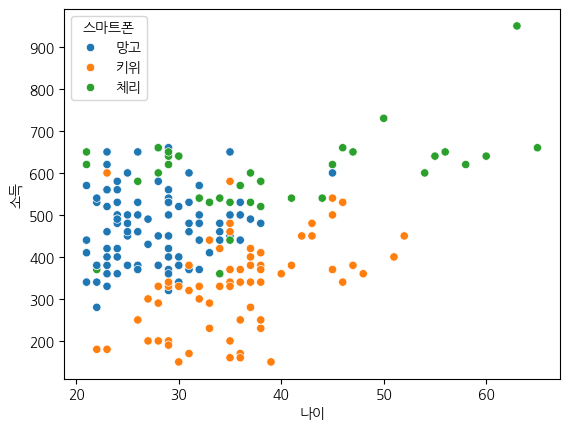

In [ ]:
import seaborn as sns
sns.scatterplot(x=df["나이"], y=df["소득"], hue=df["스마트폰"])

[실습 04-11]

In [ ]:
# 입력과 타깃 지정
X=df[['나이', '소득']]  # 입력
y=df['스마트폰']        # 타깃

# 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_idx= le.fit_transform(df['스마트폰'])

# 로지스틱 회귀 분석
model=LogisticRegression(max_iter=1000)
model.fit(X, y_idx)

# 클래스별 확률과 인덱스 예측
y_prob=model.predict_proba(X)  # 확률
y_pred=model.predict(X);       # 인덱스
print()
print("예측 확률")
print(np.round(y_prob[:10],3)); print()
print("예측된 클래스 인덱스")
print(y_pred[:10])



예측 확률
[[0.628 0.019 0.352]
 [0.058 0.001 0.941]
 [0.    1.    0.   ]
 [0.963 0.016 0.02 ]
 [0.963 0.005 0.032]
 [0.233 0.052 0.716]
 [0.512 0.487 0.002]
 [0.885 0.112 0.003]
 [0.735 0.262 0.003]
 [0.952 0.003 0.045]]

예측된 클래스 인덱스
[0 2 1 0 0 2 0 0 0 0]


[실습 04-12]

In [ ]:
print("예측_클래스_이름(처음 5개):")
print(le.inverse_transform(y_pred[:5])); print()
print("실제_클래스_이름(처음 5개):")
print(y[:5])


예측_클래스_이름(처음 5개):
['망고' '키위' '체리' '망고' '망고']

실제_클래스_이름(처음 5개):
0    망고
1    키위
2    체리
3    망고
4    체리
Name: 스마트폰, dtype: object


[실습 04-13]

크로스 엔트로피 손실 = 0.47303239744701564


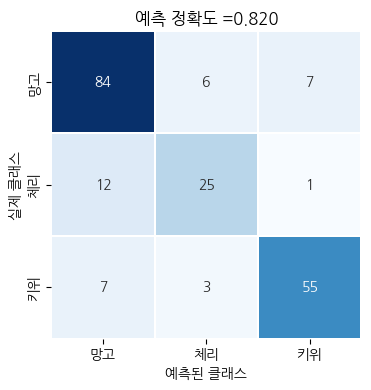

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
# 손실 계산
loss=log_loss(y_idx, y_prob)
print("크로스 엔트로피 손실 =", loss)

# 혼동 행렬 시각화
class_labels=["망고", "체리", "키위"] # 클래스 이름 리스트 (인덱스 순서대로)
cm=confusion_matrix(y_idx, y_pred)      # 혼동행렬 계산
acc=accuracy_score(y_idx, y_pred)       # 실제 클래스와 예측 클래스의 일치 비율 계산

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True,linewidths=0.1, cmap='Blues', cbar=None,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'예측 정확도 ={acc:.3f}')
plt.xlabel('예측된 클래스'); plt.ylabel('실제 클래스')
plt.show()

📌 교과서의 히트맵 그리기

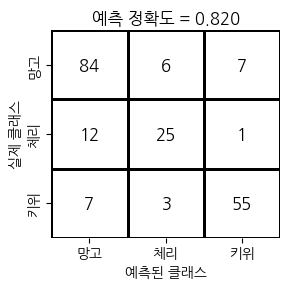

In [ ]:
plt.figure(figsize=(3, 3))
sns.heatmap(cm,
            annot=True,            # 숫자 표시
            linewidths=1.0,        # 격자 두께를 조금 키움
            linecolor='black',     # 격자 선 색상을 검정으로
            cmap=['white'],        # 전체 배경을 흰색으로 고정
            cbar=False,            # 색상 바 제거
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={"size": 12, "color": "black"}) # 숫자 크기와 색상 조절
plt.title(f'예측 정확도 = {acc:.3f}')
plt.ylabel('실제 클래스'); plt.xlabel('예측된 클래스')
plt.tight_layout() # 여백 최적화
plt.show()

[실습 04-14]

In [ ]:
# 파라미터 출력
print("가중치(클래스별):")
print(model.coef_)
print("편향(클래스별):")
print(model.intercept_); print()


가중치(클래스별):
[[-0.19379618  0.00329351]
 [ 0.00397604  0.0179794 ]
 [ 0.18982015 -0.02127291]]
편향(클래스별):
[ 5.91478258 -9.0776581   3.16287552]



[실습 04-15]

In [ ]:
interval=np.arange(150, 960,10)
X_plot=pd.DataFrame({    # 딕셔너리를 데이터프레임으로 변환
    '나이': 30,  # 고정
    '소득': interval
    })
X_plot

,나이,소득
0,30,150
1,30,160
2,30,170
3,30,180
4,30,190
...,...,...
76,30,910
77,30,920
78,30,930
79,30,940


[실습 04-16]

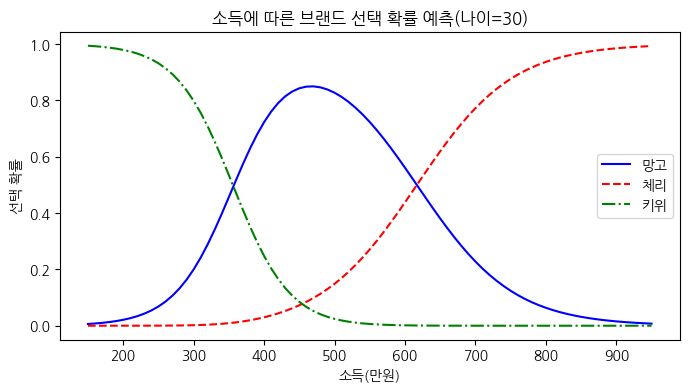

In [ ]:
# 확률 예측
probs=model.predict_proba(X_plot)

# 클래스별 확률 추출
prob_0=probs[:, 0]  # 망고
prob_1=probs[:, 1]  # 체리
prob_2=probs[:, 2]  # 키위

# 확률 시각화
plt.figure(figsize=(8, 4))
plt.plot(interval, prob_0, 'b-', label="망고")
plt.plot(interval, prob_1, 'r--', label="체리")
plt.plot(interval, prob_2, 'g-.', label="키위")

plt.xlabel("소득(만원)");plt.ylabel("선택 확률")
plt.legend(); plt.title("소득에 따른 브랜드 선택 확률 예측(나이=30)")
plt.show()

📌 나이에 따른 브랜드 선택 확률

In [ ]:
avg_income=np.mean(df["소득"])
interval=np.arange(20, 61, 1)
X1_plot=pd.DataFrame({    # 딕셔너리를 데이터프레임으로 변환
    '나이': interval,
    '소득': avg_income  # 고정
    })
X1_plot

,나이,소득
0,20,451.4
1,21,451.4
2,22,451.4
3,23,451.4
4,24,451.4
5,25,451.4
6,26,451.4
7,27,451.4
8,28,451.4
9,29,451.4


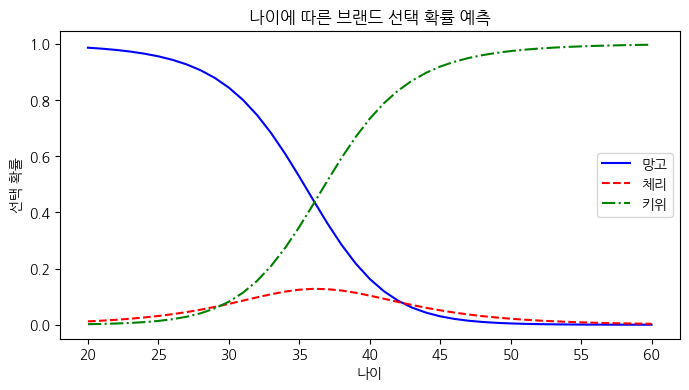

In [ ]:
# 확률 예측
probs=model.predict_proba(X1_plot)

# 클래스별 확률 추출
prob_0=probs[:, 0]  # 망고
prob_1=probs[:, 1]  # 체리
prob_2=probs[:, 2]  # 키위

# 확률 시각화
plt.figure(figsize=(8, 4))
plt.plot(interval, prob_0, 'b-', label="망고")
plt.plot(interval, prob_1, 'r--', label="체리")
plt.plot(interval, prob_2, 'g-.', label="키위")

plt.xlabel("나이");plt.ylabel("선택 확률")
plt.legend(); plt.title("나이에 따른 브랜드 선택 확률 예측")
plt.show()

[실습 04-17]

In [ ]:
import warnings; warnings.filterwarnings('ignore')
x_new=[[25, 550]]  # 나이, 소득               # 고객 피쳐 설정
probs=model.predict_proba(x_new)              # 클래스별 확률 예측
pred_index=model.predict(x_new)             # 확률이 가장 높은 클래스 인덱스
pred_brand=le.inverse_transform(pred_index)  # 역함수: 인덱스 --> 클래스 이름
print(f"이 소비자는 {np.max(probs):.3f}의 확률로 {pred_brand}를 선택할 것으로 예측됩니다.")

이 소비자는 0.877의 확률로 ['망고']를 선택할 것으로 예측됩니다.


[실습 04-18]

[[0.87673456 0.12215676 0.00110869]]


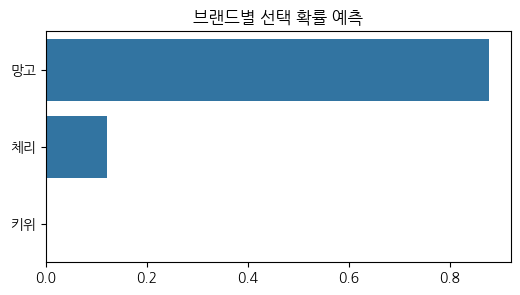

In [ ]:
# 브랜드별 선택 확률 예측
print(probs)
plt.figure(figsize=(6, 3))
sns.barplot(x=probs[0], y=class_labels) #prob[0]는 2차원 배열인 prob을 1차원 배열로 바꾼 것
plt.title("브랜드별 선택 확률 예측")
plt.show()